In [33]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#ccc',
    'axes.titlecolor': '#fff',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#ccc',
    'grid.color': '#2a2d3a',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#444',
    'figure.titlesize': 14,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

COLORS = {
    'ASH_COATED_OSMIUM': '#00c9ff',
    'INTARIAN_PEPPER_ROOT': '#ff6b6b',
    'bid': '#00e676',
    'ask': '#ff5252',
    'mid': '#ffd740',
    'trade': '#ce93d8',
}

DAYS = [-1]
DATA_PATH = '../data/ROUND1/prices_round_1_day_{}.csv'
TRADE_PATH = '../data/ROUND1/trades_round_1_day_{}.csv'

print('Libraries loaded ✓')

Libraries loaded ✓


In [34]:
price_dfs, trade_dfs = [], []

for day in DAYS:
    p = pd.read_csv(DATA_PATH.format(day), sep=';')
    t = pd.read_csv(TRADE_PATH.format(day), sep=';')
    price_dfs.append(p)
    trade_dfs.append(t)

master_prices = pd.concat(price_dfs, ignore_index=True)
master_trades = pd.concat(trade_dfs, ignore_index=True)

PRODUCTS = master_prices['product'].unique().tolist()

prices = master_prices[~((master_prices['product'] == 'INTARIAN_PEPPER_ROOT') & (master_prices['mid_price'] == 0))]
prices = master_prices[~((master_prices['product'] == 'ASH_COATED_OSMIUM') & (master_prices['mid_price'] == 0))]
prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,INTARIAN_PEPPER_ROOT,10991.0,15.0,NaN,NaN,NaN,NaN,11006.0,10.0,11009.0,15.0,NaN,NaN,10998.5,0.0
1,-1,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10003.0,29.0,NaN,NaN,NaN,NaN,10003.0,0.0
2,-1,100,ASH_COATED_OSMIUM,9984.0,11.0,NaN,NaN,NaN,NaN,10000.0,11.0,10003.0,22.0,NaN,NaN,9992.0,0.0
3,-1,100,INTARIAN_PEPPER_ROOT,10994.0,9.0,10991.0,21.0,NaN,NaN,11006.0,9.0,11009.0,21.0,NaN,NaN,11000.0,0.0
4,-1,200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,20.0,NaN,NaN,10001.0,15.0,10003.0,20.0,NaN,NaN,9993.0,0.0


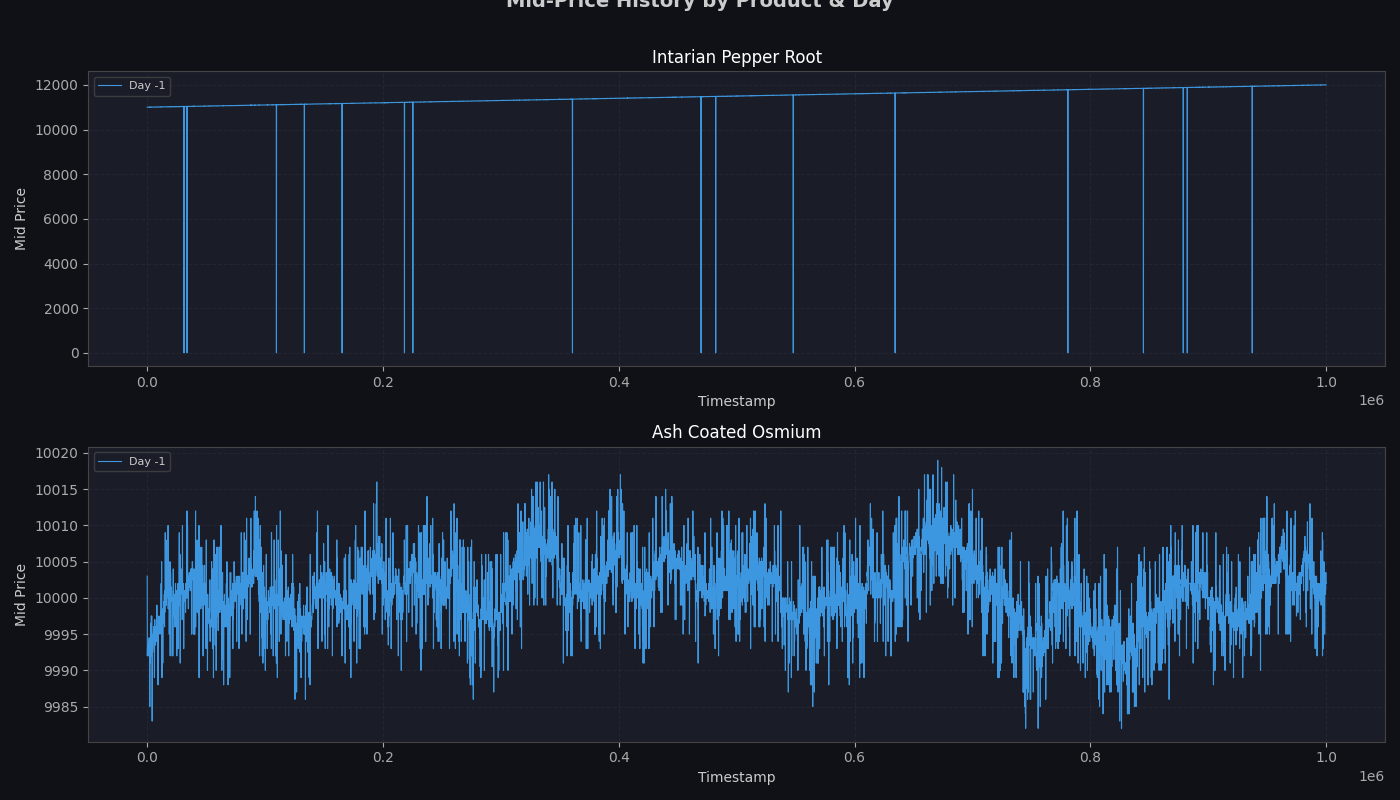

In [35]:
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(14, 8), sharex=False)
fig.suptitle('Mid-Price History by Product & Day', fontsize=14, fontweight='bold', y=1.01)

day_colors = {-2: '#5c6bc0', -1: '#42a5f5', 0: '#00e5ff'}
day_labels = {-2: 'Day -2', -1: 'Day -1', 0: 'Day 0'}

for ax, product in zip(axes, PRODUCTS):
    sub = prices[prices['product'] == product]
    for day in DAYS:
        d = sub[sub['day'] == day].sort_values('timestamp')
        ax.plot(d['timestamp'], d['mid_price'],
                color=day_colors[day], lw=0.8, label=day_labels[day], alpha=0.9)
    ax.set_title(product.replace('_', ' ').title())
    ax.set_ylabel('Mid Price')
    ax.set_xlabel('Timestamp')
    ax.grid(True)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('mid_price_history.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

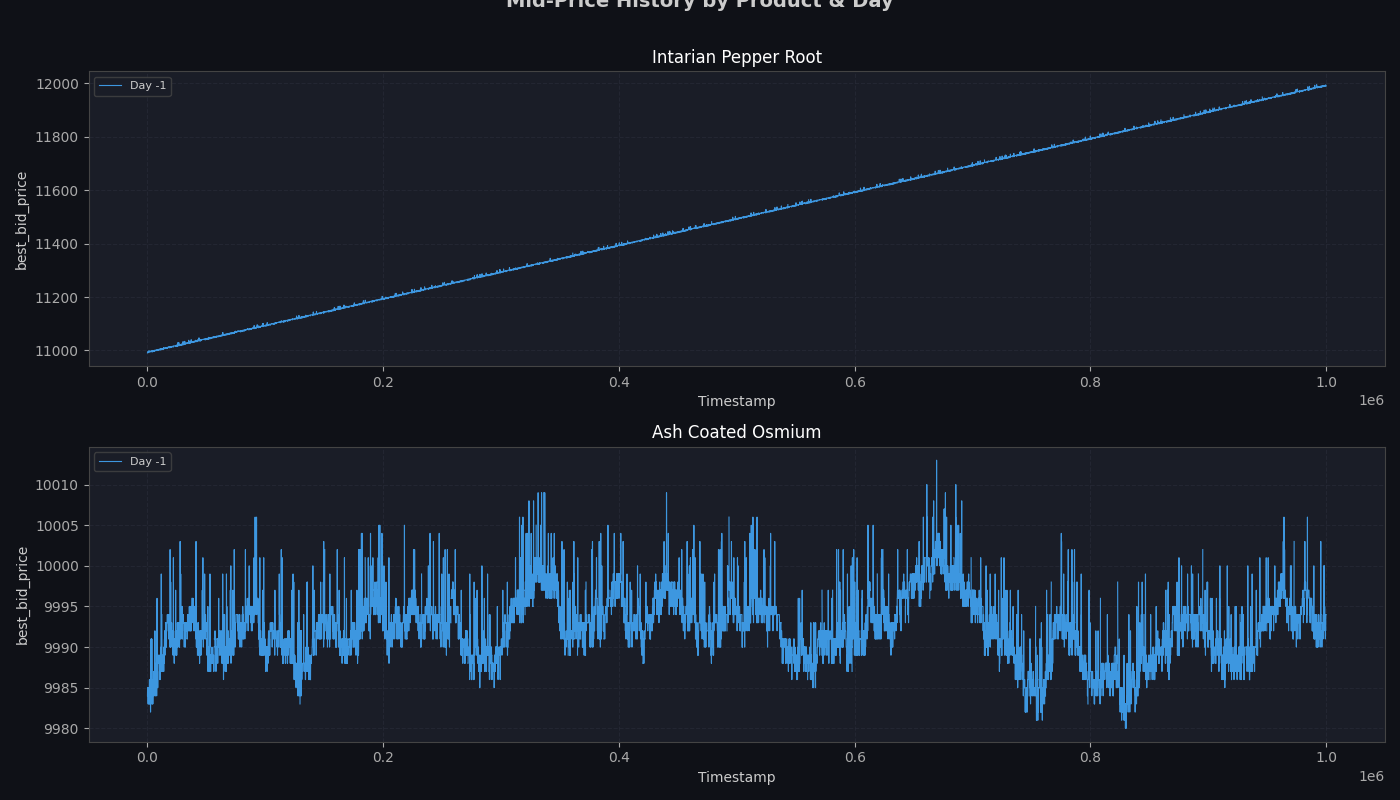

In [36]:
DAYS = [-1]
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(14, 8), sharex=False)
fig.suptitle('Mid-Price History by Product & Day', fontsize=14, fontweight='bold', y=1.01)

day_colors = {-2: '#5c6bc0', -1: '#42a5f5', 0: '#00e5ff'}
day_labels = {-2: 'Day -2', -1: 'Day -1', 0: 'Day 0'}

for ax, product in zip(axes, PRODUCTS):
    sub = prices[prices['product'] == product]
    for day in DAYS:
        d = sub[sub['day'] == day].sort_values('timestamp')
        ax.plot(d['timestamp'], d['bid_price_1'],
                color=day_colors[day], lw=0.8, label=day_labels[day], alpha=0.9)
    ax.set_title(product.replace('_', ' ').title())
    ax.set_ylabel('best_bid_price')
    ax.set_xlabel('Timestamp')
    ax.grid(True)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('bid_price_history.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

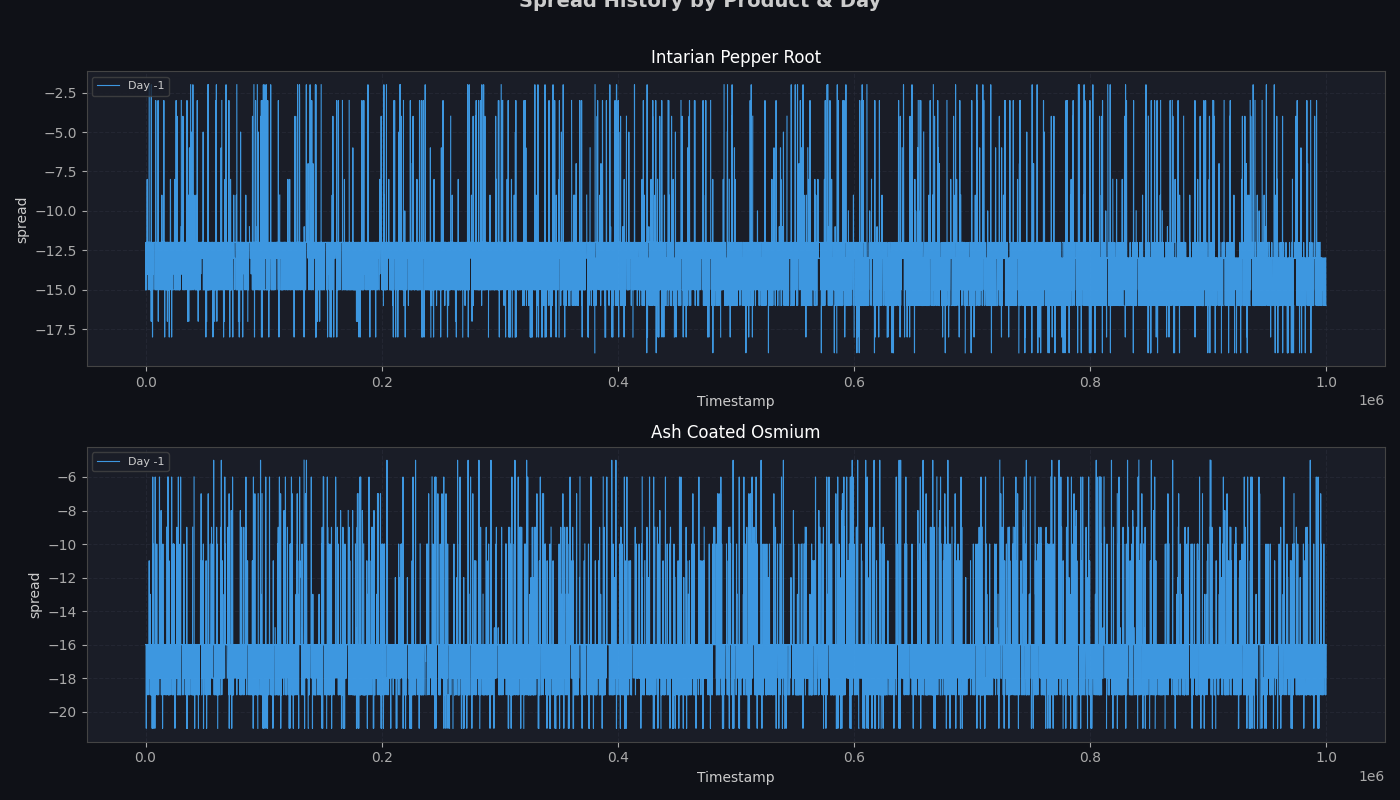

In [ ]:
prices['spread'] = -prices['bid_price_1'] + prices['ask_price_1']
prices.loc[(prices['ask_price_1'] == 0) | (prices['bid_price_1'] == 0), 'spread'] = 0

DAYS = [-1]
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(14, 8), sharex=False)
fig.suptitle('Spread History by Product & Day', fontsize=14, fontweight='bold', y=1.01)

day_colors = {-2: '#5c6bc0', -1: '#42a5f5', 0: '#00e5ff'}
day_labels = {-2: 'Day -2', -1: 'Day -1', 0: 'Day 0'}

for ax, product in zip(axes, PRODUCTS):
    sub = prices[prices['product'] == product]
    for day in DAYS:
        d = sub[sub['day'] == day].sort_values('timestamp')
        ax.plot(d['timestamp'], d['spread'],
                color=day_colors[day], lw=0.8, label=day_labels[day], alpha=0.9)
    ax.set_title(product.replace('_', ' ').title())
    ax.set_ylabel('spread')
    ax.set_xlabel('Timestamp')
    ax.grid(True)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('spread_history.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

